# Find Transition States using ASE and PyMolpro
# Transition State CH3-Br to CH3-Cl

## Using the scan method

First, we will parallize the code. Therefore, we need to add a line to the file called .bashrc in the home directory. 
1. Open the terminal
2. Type 'cd' to get to the home directory
3. Type vi .bashrc to open the file in the terminal
4. Press 'i' to get into insert mode
5. Add the following line to the end of the file: export MOLPRO_OPTIONS="-n4"
6. Press 'ESC' to get out of insert mode
7. Type ':wq' to save and quit the file
8. Type 'source .bashrc' to apply the changes
9. Restart VS Code to make sure the changes are applied

First, all necessary modules are imported.

In [1]:
from ase.io import read, write
from ase.visualize import view
from ase.optimize import BFGS
# from pymolpro import ASEMolpro
import numpy as np
from ase.constraints import FixBondLength
from ase import Atoms
from ase.build.rotate import minimize_rotation_and_translation
from ase.vibrations import Vibrations
from ase.mep import NEB
from ase.units import kJ,mol
from ase.optimize import QuasiNewton
from ase.thermochemistry import IdealGasThermo
import matplotlib.pyplot as plt

### Prepare structures

We need to generate the structures of our reactants and products by Avogadro for example. It should be one xyz file containing the reactant and one xyz file containing the product. In the reactant, the Cl should be 3.5 Angstrom away from the C, and in the product, the Br should be around 3.2 Angstrom away from the C. Due to time constraints in this practical, you can find the structures on Ilias.

Then, we need to read them and save them in an 'Atoms' object using ASE's read function. As an information, append to the info of each structure the charge (molecule.info['charge'] = -1). This is NOT read by the calculator later, so you need to enter the charge there too.

In [2]:
# write code here for reactant and product
reactant = read("CH3Br-Cl_not_opt.xyz")
reactant.info["charge"] = -1
product = read("CH3Cl-Br_not_opt.xyz")
product.info["charge"] = -1

Now we want to have a closer look at the structures. Print for example the chemical symbols or relevant bond distances. Vizualize the structures to check whether they look resonable, using the viewer='x3d' for example.

In [6]:
# print chemical symbols and distances between C and Cl/Br for reactant and product
print("Reactant:")
print(reactant.get_chemical_symbols())
print(reactant.get_distance(0, 4))

print("Product:")
print(product.get_chemical_symbols())
print(product.get_distance(0, 5))

Reactant:
['C', 'H', 'H', 'H', 'Cl', 'Br']
3.500000000624295
Product:
['C', 'H', 'H', 'H', 'Cl', 'Br']
3.5000000008378067


In [3]:
# view reactant and product structures. Do they look reasonable?
view(reactant, viewer="x3d")
# view(product, viewer="x3d")

Optimize both structures to have a good starting point for the scan. If they are drifting too far apart or form an unwanted geometry during the optimization, you can fix the bondlength between the C and Cl or Br atom. Check the optimized structures again by visualizing them and printing the important bond lengths.

The used functional is PBE with a def2-SVP basis set and density fitting. The convergence criteria for the optimization are set to 0.05 eV/Å for the forces.

Don't forget to set the charge of the calculator to -1 for both structures.

At the end, visualize the optimized structures again and check whether they look resonable.

In [49]:
# optimize reactant and product structures. Do they look reasonable after optimization? If not, use constraints to fix the bond lengths of the C-Cl or C-Br bond to prevent the reactants from drifting apart. Don't forget to set the charge of the calculator to -1.

# Example for constraints:
# c_idx = 0
# cl_idx = 4
# constraintCCl = FixBondLength(c_idx, cl_idx)      --> this fixes the bond length between the atoms with index c_idx and cl_idx during the optimization
# CH3Br.set_constraint(constraintCCl)

reactant.calc = ASEMolpro(ansatz='PBE/def2-SVP', density_fitting=True, charge=-1)
reactant.set_constraint(FixBondLength(0, 4))
with BFGS(reactant, trajectory='reactant.traj') as opt:
    opt.run(fmax=0.05)

product.calc = ASEMolpro(ansatz='PBE/def2-SVP', density_fitting=True, charge=-1)
product.set_constraint(FixBondLength(0, 5))
with BFGS(product, trajectory='product.traj') as opt:
    opt.run(fmax=0.05)

      Step     Time          Energy          fmax
BFGS:    0 16:01:01   -83625.664062        0.722149
BFGS:    1 16:01:12   -83625.676892        0.513839
BFGS:    2 16:01:22   -83625.693385        0.124742
BFGS:    3 16:01:32   -83625.694257        0.064442
BFGS:    4 16:01:42   -83625.694452        0.049769
      Step     Time          Energy          fmax
BFGS:    0 16:01:51   -83626.207098        1.000824
BFGS:    1 16:02:00   -83626.226912        0.586557
BFGS:    2 16:02:10   -83626.240773        0.061261
BFGS:    3 16:02:19   -83626.241173        0.028009


In [ ]:
# visualize reactant and product.
view(reactant, viewer="x3d")
view(product, viewer="x3d")

To make it easier to look at the structures, we minimize the rotation and translation between the reactants and products. When vizualizing the structures again, they should now be in a similar orientation.

In [10]:
# minimize_rotation_and_translation(molecule1, molecule2)
minimize_rotation_and_translation(reactant, product)

### Perform the scan calculation

Now we are ready to perform the scan calculation. We will vary the bond distance that you think is representing the reaction coordinate the most. For each step, we will optimize the rest of the structure while keeping this bond distance fixed. Show the supervisor which bond distance you are scanning before you start the scan, to make sure that you don't need to repeat the time consuming scan calculation.

So first, we need to define indices of the atoms which will be fixed and the range of bond distances to scan as an array. We use the product as starting structure, so the first value in the arrray should be the bond distance(s) in the product structure and the last value(s) the bond distance(s) in the reactant structure. To be time efficient, we will use 6 steps for the scan. You can also make the stepsize closer in the region where you expect the transition state to be.

In [11]:
# scan from product to reactants
distances = np.linspace(3.5, reactant.get_distance(0, 5), 12)
idx_atom1 = 0
idx_atom2 = 5

# define indices of the atoms which will be fixed 
# print the bond distances in the reactant and product structure to define the range of bond distances to scan as an array.
# make an evenly spaced array called 'distances' of bond distances between the reactant and product structure. You can also make the stepsize closer in the region where you expect the transition state to be.
# print your array

Now, we can perform the scan. For each distance in the defined array, we optimize the structure while keeping the bond distances fixed. We save the energies, important distances and postitions of the atoms for each step to evaluate them later.
We can use looser convergence criteria for the forces of 0.1 eV/Å to speed up the calculation.

In [12]:
# make an array to store the energies and the final bond distances after optimization for each step of the scan using np.zeros() or []. Also, make an empty list to store the final positions for each step of the scan using [].
energies = np.empty(len(distances))
final_bond_lengths = np.empty(len(distances))
positions = []

# copy the product structure as input structure for the scan calculation and set the calculator. We will optimize the structure for each step of the scan, so we need to set the calculator for the scan structure only once in the beginning. Don't forget to set the charge of the calculator to -1.
scan = product.copy()
scan.calc = ASEMolpro(ansatz='PBE/def2-SVP', density_fitting=True, charge=-1)

# Loop over the defined array of bond distances and perform the scan calculation:
for idx, d in enumerate(distances):
    # set the name of the trajectory file for this step of the scan in case you want to visualize the optimization later
    trajfile = f"ts_{round(d,2)}.traj"      

    # to see at which step the program is, print the bond distance that you are setting for this step of the scan.
    print(f"Setting C-Br distance to {round(d,2)} Å")
    # set the bond distance between atom1 and atom2 to the value in the array d. Then, constrain the bond length between these two atoms to keep it fixed during the optimization.
    scan.set_distance(idx_atom1,idx_atom2, d)         
    constraint = FixBondLength(idx_atom1,idx_atom2)
    scan.set_constraint(constraint)
    
    # perform the optimization for this step. The convergence criterion for the optimization is set to 0.1 eV/Å for the forces. You can save the trajectory of the optimization using trajfile as defined above.
    with BFGS(scan, trajectory=trajfile) as opt:
        opt.run(fmax=0.1)

    # save the energy and the distance ("get_distance()") in the arrays at index idx and append the atom positions ("get_positions()") to the list you defined in the beginning.
    energies[idx] = scan.get_total_energy()
    final_bond_lengths[idx] = scan.get_distance(idx_atom1, idx_atom2)
    positions.append(scan.get_positions())

    # print the energy after the optimization and verify that the bond distance is still the same as the value in the array d.
    print(f"Energy: {energies[idx]:.3f}, Bond length still the same? {np.allclose(final_bond_lengths[idx], d)}")
    

Setting C-Br distance to 3.5 Å
      Step     Time          Energy          fmax
BFGS:    0 15:09:19   -83626.241173        0.028009
Energy: -83626.241, Bond length still the same? True
Setting C-Br distance to 3.36 Å
      Step     Time          Energy          fmax
BFGS:    0 15:09:29   -83626.216786        1.209212
BFGS:    1 15:09:38   -83626.248147        0.672572
BFGS:    2 15:09:48   -83626.258551        0.179725
BFGS:    3 15:09:58   -83626.260195        0.160790
BFGS:    4 15:10:08   -83626.262351        0.080790
Energy: -83626.262, Bond length still the same? True
Setting C-Br distance to 3.23 Å
      Step     Time          Energy          fmax
BFGS:    0 15:10:18   -83626.231742        1.098439
BFGS:    1 15:10:27   -83626.257074        0.643906
BFGS:    2 15:10:37   -83626.267163        0.199140
BFGS:    3 15:10:46   -83626.269156        0.183400
BFGS:    4 15:10:56   -83626.272133        0.086946
Energy: -83626.272, Bond length still the same? True
Setting C-Br distance to

To make sure that our scan looks reasonable, we plot the energy as a function of the scanned bond distance(s) using the scatter plot of  matplotlib.

Text(0, 0.5, 'Energy [kJ/mol]')

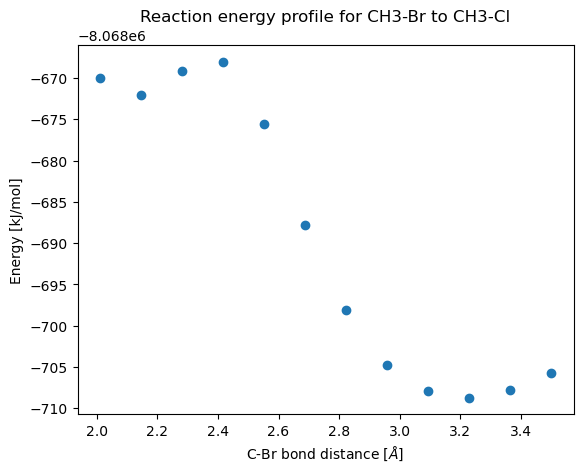

In [13]:
# plot the energy as a function of the bond distance using matplotlib. Where is the transition state located? you can use matplotlib, which was imported as plt in the beginning of the notebook.
energies *= mol/kJ

plt.scatter(distances, energies)
plt.title('Reaction energy profile for CH3Br + Cl -> CH3Cl + Br')
plt.xlabel(r'C-Br bond distance [$\AA$]')
plt.ylabel('Energy [kJ/mol]')

Now we want to plot the transition state structure. Thus, we create an Atoms object, e.g. by copying the reactant, and changing the positions of the atoms to the ones of the transition state. Then, we can visualize it as before. We also can save this structure as an xyz file for future use.

In [52]:
# find index of transition state in the array of energies
ts_index = 3

# copy the product structure again and set the positions to the positions of the transition state that you saved in the list. Visualize the transition state structure. Does it look reasonable?
ts = product.copy()
ts.set_positions(positions[ts_index], apply_constraint=False)
view(ts, viewer='x3d')

Save the geometry of the transition state in an xyz file for future use. You can do this by using the save function of ASE.

In [15]:
# save the transition state structure as "ts_scan.xyz".
pos_ts = ts.get_positions()
sym_ts = ts.get_chemical_symbols()
save_ts = Atoms(positions=pos_ts, symbols=sym_ts)
write('ts_scan.xyz', save_ts)

In [4]:
ts = read('ts_scan.xyz')
view(ts, viewer='x3d')

To vizualize the scan, there is a function that appends the coordinates of each optimized step into a single xyz file. This file can then be opened by the visualization program of vmd. You can view the scan by clicking on the play button on the bottom right. Maybe you need to reduce the speed on the slider left of the play button.

In [16]:
# input in function: 
# - filepath: the name of the file to which the trajectory will be written. Be aware: If the file already exists, the new structures will  
#   be appended to the end of the file.
# - positions: a list of arrays of the positions of each step of the scan. This is the list of your for loop of your scan earlier.
# - symbols: a list of the chemical symbols of the atoms in the system. You can get this from the product structure using "get_chemical_symbols()".

def write_xyz_traj(filepath:str, positions:list, symbols:list):
    num_atoms = len(positions[0])

    # Open file in append mode ('a') to ensure all structures are added sequentially
    with open(filepath, 'a') as f:
        print(f"Writing {len(positions)} structures to {filepath}...")
        
        for pos in positions:
            f.write(f"{num_atoms}\n\n")

            for symbol, (x, y, z) in zip(symbols, pos):
                f.write(f"{symbol}\t{x:10.6f}\t{y:10.6f}\t{z:10.6f}\n")
            
        print("Writing complete.")

In [17]:
write_xyz_traj("transition_scan.xyz", positions, product.get_chemical_symbols())

Writing 12 structures to transition_scan.xyz...
Writing complete.


To proof that we found a transition state, we perform a frequency calculation at the transition state structure. We should find exactly one imaginary frequency. We also can visualize the normal mode corresponding to this imaginary frequency to see that it represents the reaction coordinate.

As we did only 6 steps in our scan, the transition state structure might not be very accurate and can have more imaginary frequencies, where all but one should be much smaller, which is not important for this exercise. In a real case, one would now refine the transition state structure by performing a transition state optimization starting from the found structure.

In [18]:
!ase gui transition_scan.xyz

In [53]:
# perform vibrational analysis, look at your code from day4
ts.calc = ASEMolpro(ansatz='PBE/def2-SVP', density_fitting=True, charge=-1)
vib_ts = Vibrations(ts, name="transition")
vib_ts.clean()
vib_ts.run()
vib_ts.summary()

---------------------
  #    meV     cm^-1
---------------------
  0    1.9i     15.6i
  1    0.5i      4.3i
  2    1.0       8.1
  3    2.9      23.0
  4    4.3      34.4
  5    4.3      34.5
  6   13.2     106.3
  7   13.6     109.6
  8   28.1     226.6
  9   38.6     311.5
 10   95.9     773.1
 11   96.5     778.5
 12  140.5    1132.9
 13  170.7    1376.6
 14  170.8    1377.4
 15  369.5    2980.0
 16  386.8    3119.6
 17  388.0    3129.6
---------------------
Zero-point energy: 0.962 eV


In [20]:
# save mode of imaginary frequency (always the first one) as traj file and visualize it using ase gui
for mode in [0]:
    vib_ts.write_mode(mode)

Calculate the activation energy and reaction energy in kJ/mol.

In ase, the energy is given in eV, so you need to convert it to kJ/mol. You can multiply the result in eV by (mol/kJ). This is enabled due to the units module of ase, which is imported in the beginning.

In [54]:
print(f"Activation energy: {(ts.get_total_energy() - reactant.get_total_energy()) * mol/kJ:.3f}")
print(f"Reaction energy: {(product.get_total_energy() - reactant.get_total_energy()) * mol/kJ:.3f}")

Activation energy: 5.266
Reaction energy: -52.751


Now, you calculated the electronic reaction and activation energy. Usually, we are interested in the Gibbs free energy, which also includes the entropic contributions. To calculate the activation energy and the reaction energy, we would need to perform vibrational calculations for the reactants and the product. From that, the zero-point energy and thermal corrections to the free energy can be calculated. To save time, we won't do this here, but you learned on day 4 how to do this.

Awesome, you just performed your first transition state search using the scan method!

## Use the NEB method to find the TS

For the nudged elastic band (NEB) method, we need to create a set of images between the reactant and product structure. ASE has a convenient method to generate these images by interpolation between the two structures.

We start by creating 7 images, including the reactant and product structure. The images are saved in a list. The first structure needs to be the reactant and the last one the product. All intermediate images can be copies of either the reactant or product structure.

In [22]:
n_images = 7
images = [reactant]                                        # first image is the reactant, which you optimized in the beginning of the notebook
images += [reactant.copy() for i in range(n_images-2)]     # n_image - 2 intermediate images are added, which are interpolated later
images += [product]                                        # last image is the product, which you optimized in the beginning of the notebook

Then, we do the interpolation between the images to get a better initial guess for the NEB calculation. We can use either linear interpolation or the more advanced IDPP method, which usually works better.

We create an 'neb' object, that contains our list of images and the method we use, which is 'spline'. we want to use a spring constant of 0.2 eV/Å.

Next, we call the function interpolate with the 'idpp' method. We do not want to apply the constraints we made earlier during the neb.

In [23]:
# define the neb object using the method spline.
neb = NEB(images, k=0.2, method = 'spline')
# interpolate the 5 images using the idpp method. This will give you a better guess for the transition state structure than linear interpolation.
neb.interpolate(method='idpp', apply_constraint=False)

We can view the images one after another and check if they look like a reasonable starting guess.

In [30]:
view(images[5], viewer='x3d')

For the calculation, we need to attach a calculator for each image. We again use PBE/def2-SVP and density fitting. The charge must be set to -1.

In [31]:
for image in images:
    image.calc = ASEMolpro(ansatz='PBE/def2-SVP', density_fitting=True, charge=-1)

Now, we can perform the optimization, where each image is optimized, until the forces are below the threshold of 0.5 eV/Å.

In [32]:
optimizer = BFGS(neb, trajectory='neb_opt.traj')
optimizer.run(fmax=0.5)

      Step     Time          Energy          fmax
BFGS:    0 15:32:06   -83624.380739        1.208419
BFGS:    1 15:33:08   -83624.456342        1.063292
BFGS:    2 15:34:01   -83624.366708        3.586706
BFGS:    3 15:34:52   -83624.269723        2.211481
BFGS:    4 15:35:45   -83623.588860        1.826457
BFGS:    5 15:36:34   -83623.872082        1.398030
BFGS:    6 15:37:27   -83624.033531        0.749950
BFGS:    7 15:38:19   -83623.986718        0.873923
BFGS:    8 15:39:17   -83623.924489        1.415108
BFGS:    9 15:40:18   -83623.982370        1.357851
BFGS:   10 15:41:19   -83624.188359        1.518541
BFGS:   11 15:42:12   -83624.155132        1.179746
BFGS:   12 15:43:04   -83624.181324        0.637664
BFGS:   13 15:43:58   -83624.156228        0.344256


np.True_

From the list of images, we can extract the energies and positions of all atoms for each image.

In [34]:
energies = np.empty(len(images))
positions = []
for i, image in enumerate(images):
    energies[i] = image.get_total_energy()
    positions.append(image.get_positions())
    print("="*20)
    print(f"Image {i+1}:")
    print(f"  Energy: {energies[i]:.3f}")
    print("="*20, end="\n\n")
    

Image 1:
  Energy: -83625.694

Image 2:
  Energy: -83625.690

Image 3:
  Energy: -83625.687

Image 4:
  Energy: -83625.640

Image 5:
  Energy: -83624.937

Image 6:
  Energy: -83624.156

Image 7:
  Energy: -83626.241




Locate the index of the transition state.

In [36]:
# Pick the index with the highest energy
ts_index = 5

To make sure that the neb looks reasonable, we plot the energy as a function of the number of each image using the plot of  matplotlib.

Text(0, 0.5, 'Energy [eV]')

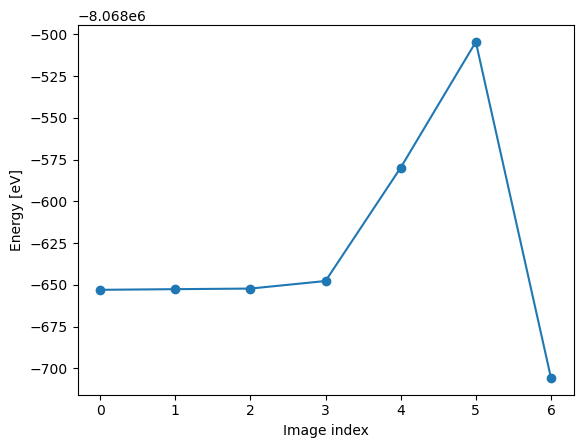

In [ ]:
plt.plot(range(n_images), energies*mol/kJ, 'o-')
plt.xlabel("Image index")
plt.ylabel("Energy [kj/mol]")

We can save the final neb path and the transition state structure as xyz files.
We also want to visualize the transition state and compare it to the transition state of the scan.

In [37]:
# save neb path using the function write_xyz_traj that was defined earlier in the notebook.
write_xyz_traj("neb_transition.xyz", positions, image.get_chemical_symbols())

Writing 7 structures to neb_transition.xyz...
Writing complete.


In [38]:
# save the structure of the image of the transition state as xyz file, in case you want to use it later.
write("neb_transition_state.xyz", images[ts_index])

In [39]:
# visualize the transition state
view(images[ts_index], viewer="x3d")

To proof that we found a transition state, we again perform a frequency calculation of the transition state structure. We can visualize the normal mode corresponding to this imaginary frequency to see that it represents the reaction coordinate.

In [55]:
# calculate vibrations of the transition state
ts = images[ts_index].copy()
ts.calc = ASEMolpro(ansatz='PBE/def2-SVP', density_fitting=True, charge=-1)
vib_ts = Vibrations(ts, name="neb_transition")
vib_ts.clean()
vib_ts.run()
vib_ts.summary()

---------------------
  #    meV     cm^-1
---------------------
  0    1.9i     15.6i
  1    0.5i      4.3i
  2    1.0       8.1
  3    2.9      23.0
  4    4.3      34.4
  5    4.3      34.5
  6   13.2     106.3
  7   13.6     109.6
  8   28.1     226.6
  9   38.6     311.5
 10   95.9     773.1
 11   96.5     778.5
 12  140.5    1132.9
 13  170.7    1376.6
 14  170.8    1377.4
 15  369.5    2980.0
 16  386.8    3119.6
 17  388.0    3129.6
---------------------
Zero-point energy: 0.962 eV


In [42]:
# save mode of imaginary frequency as traj file and visualize it using ase gui
for mode in [0]:
    vib_ts.write_mode(mode)

In [45]:
# calculate Gibbs free energy of the transition state.
thermo = IdealGasThermo(
    vib_energies=vib_ts.get_energies(),
    potentialenergy=ts.get_potential_energy(),
    atoms=ts,
    geometry='nonlinear',
    symmetrynumber=3,
    spin=0,
    ignore_imag_modes=True
)
GCH3OH = thermo.get_gibbs_energy(temperature=298.15, pressure=101325.0)

Enthalpy components at T = 298.15 K:
E_pot             -83624.156 eV
E_ZPE                  0.873 eV
Cv_trans (0->T)        0.039 eV
Cv_rot (0->T)          0.039 eV
Cv_vib (0->T)          0.078 eV
(C_v -> C_p)           0.026 eV
-------------------------------
H                 -83623.103 eV

Entropy components at T = 298.15 K and P = 101325.0 Pa:
                           S               T*S
S_trans (1 bar)    0.0017578 eV/K        0.524 eV
S_rot              0.0010708 eV/K        0.319 eV
S_elec             0.0000000 eV/K        0.000 eV
S_vib              0.0005067 eV/K        0.151 eV
S (1 bar -> P)    -0.0000011 eV/K       -0.000 eV
-------------------------------------------------
S                  0.0033341 eV/K        0.994 eV

Free energy components at T = 298.15 K and P = 101325.0 Pa:
    H     -83623.103 eV
 -T*S         -0.994 eV
-----------------------
    G     -83624.097 eV


/home/CompChem3/miniconda3/envs/compchem/lib/python3.11/site-packages/ase/thermochemistry.py:823: UserWarning: 1 imag modes removed
  warn(f"{n_imag} imag modes removed", UserWarning)


In [58]:
# calculate the activation and reaction energy and print the results in kJ/mol.
print(f"Activation energy: {(ts.get_total_energy() - reactant.get_total_energy()) * mol/kJ:.3f}")
print(f"Reaction energy: {(product.get_total_energy() - reactant.get_total_energy()) * mol/kJ:.3f}")

Activation energy: 148.416
Reaction energy: -52.751
